# Logistic regression trained with batch gradient descent

CSI4106 Introduction to Artificial Intelligence

Marcel Turcotte (School of Electrical Engineering and Computer Science,
University of Ottawa)  
2026-09-19

This notebook implements binary logistic regression with NumPy. The
model uses binary cross-entropy and batch gradient descent, matching the
equations developed in Lecture 6.

# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Logistic regression implementation

For a matrix $X_b$ that includes an intercept column, the implementation
follows four equations:

$$
z = X_b\theta,
\qquad
\hat{p} = \sigma(z),
$$

$$
\nabla J(\theta) = \frac{1}{N}X_b^\top(\hat{p}-y),
\qquad
\theta \leftarrow \theta-\alpha\nabla J(\theta).
$$

Here, $\alpha$ is the learning rate.

In [2]:
class LogisticRegression:
    """Binary logistic regression trained with batch gradient descent.

    Parameters
    ----------
    learning_rate : float, default=0.1
        Step size used by gradient descent.
    max_iter : int, default=1000
        Number of gradient-descent updates.

    Notes
    -----
    The implementation expects labels in {0, 1}. It adds the intercept
    internally and does not use regularization or early stopping.
    """

    def __init__(self, learning_rate: float = 0.1, max_iter: int = 1000):
        if learning_rate <= 0:
            raise ValueError("learning_rate must be positive.")
        if max_iter <= 0:
            raise ValueError("max_iter must be positive.")

        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self._theta = None
        self._loss_history = None
        self._n_features = None
        self._fitted = False

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        """Estimate the parameters from a training set."""
        X = self._as_2d_array(X, name="X")
        y = self._as_1d_array(y, name="y")

        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must contain the same number of examples.")
        self._check_binary_labels(y)

        n_examples, n_features = X.shape
        self._n_features = n_features
        Xb = self._add_intercept(X)

        # Zero initialization is sufficient because the objective is convex.
        self._theta = np.zeros(n_features + 1, dtype=float)
        self._loss_history = []

        for _ in range(self.max_iter):
            probabilities = self._sigmoid(Xb @ self._theta)
            gradient = (Xb.T @ (probabilities - y)) / n_examples
            self._theta -= self.learning_rate * gradient

            updated_probabilities = self._sigmoid(Xb @ self._theta)
            self._loss_history.append(self._bce_loss(updated_probabilities, y))

        self._fitted = True
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Return the predicted probability of the positive class."""
        self._ensure_fitted()
        X = self._as_2d_array(X, name="X")
        self._ensure_same_n_features(X)
        return self._sigmoid(self._add_intercept(X) @ self._theta)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Return class predictions using the specified threshold."""
        if not 0 <= threshold <= 1:
            raise ValueError("threshold must be between 0 and 1.")
        return (self.predict_proba(X) >= threshold).astype(int)

    @property
    def intercept_(self) -> float:
        """Return the fitted intercept."""
        self._ensure_fitted()
        return float(self._theta[0])

    @property
    def coef_(self) -> np.ndarray:
        """Return a copy of the fitted feature coefficients."""
        self._ensure_fitted()
        return self._theta[1:].copy()

    def get_loss_history(self) -> list[float]:
        """Return the binary-cross-entropy values recorded during training."""
        self._ensure_fitted()
        return list(self._loss_history)

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        """Compute the sigmoid without overflowing for large negative values."""
        z = np.asarray(z, dtype=float)
        result = np.empty_like(z)
        positive = z >= 0
        result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
        exp_z = np.exp(z[~positive])
        result[~positive] = exp_z / (1.0 + exp_z)
        return result

    @staticmethod
    def _bce_loss(probabilities: np.ndarray, y: np.ndarray) -> float:
        probabilities = np.clip(probabilities, 1e-12, 1.0 - 1e-12)
        return float(
            -np.mean(
                y * np.log(probabilities)
                + (1 - y) * np.log(1 - probabilities)
            )
        )

    @staticmethod
    def _as_2d_array(X, name: str) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError(
                f"{name} must be a 2D array of shape (n_examples, n_features)."
            )
        return X

    @staticmethod
    def _as_1d_array(y, name: str) -> np.ndarray:
        y = np.asarray(y, dtype=float)
        if y.ndim != 1:
            raise ValueError(f"{name} must be a 1D array of shape (n_examples,).")
        return y

    @staticmethod
    def _check_binary_labels(y: np.ndarray) -> None:
        if not np.array_equal(np.unique(y), np.array([0.0, 1.0])):
            raise ValueError("y must contain both binary labels 0 and 1.")

    @staticmethod
    def _add_intercept(X: np.ndarray) -> np.ndarray:
        return np.column_stack([np.ones(X.shape[0]), X])

    def _ensure_fitted(self) -> None:
        if not self._fitted or self._theta is None:
            raise RuntimeError("Call fit(X, y) before using the fitted model.")

    def _ensure_same_n_features(self, X: np.ndarray) -> None:
        if X.shape[1] != self._n_features:
            raise ValueError(
                f"X has {X.shape[1]} features; the model was fitted with "
                f"{self._n_features}."
            )

# A two-dimensional example

The two features let us see the probability surface, decision boundary,
and normal vector directly.

In [3]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=2.5,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

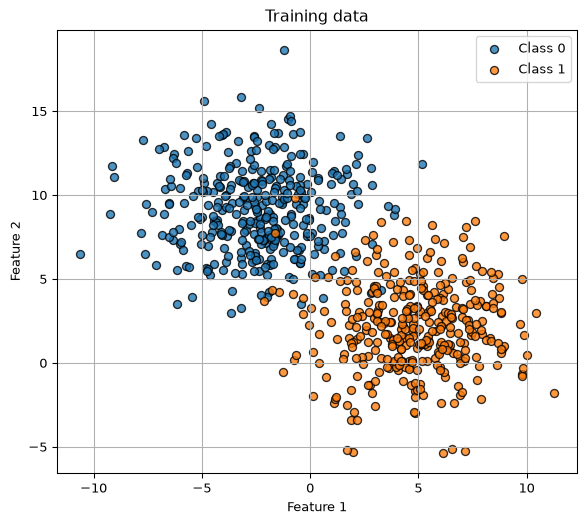

In [4]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    color="tab:blue",
    edgecolor="black",
    alpha=0.8,
    label="Class 0",
)
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color="tab:orange",
    edgecolor="black",
    alpha=0.8,
    label="Class 1",
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training data")
plt.legend()
plt.grid(True)
plt.show()

# Training

In [5]:
model = LogisticRegression(learning_rate=0.1, max_iter=500)
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Feature coefficients:", model.coef_)

Intercept: 1.0100587136980153
Feature coefficients: [ 1.06044862 -0.48332183]

The loss decreases as batch gradient descent updates the parameter
vector.

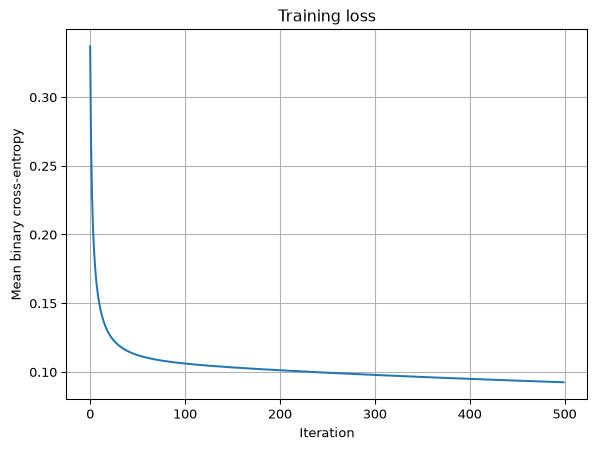

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(model.get_loss_history())
plt.xlabel("Iteration")
plt.ylabel("Mean binary cross-entropy")
plt.title("Training loss")
plt.grid(True)
plt.show()

# Probability surface and decision boundary

The green contour shows where $P(y=1\mid x)=0.5$. Let
$w=(\theta_1,\theta_2)^\top$ denote the fitted feature-weight vector.
This vector is normal to the boundary.

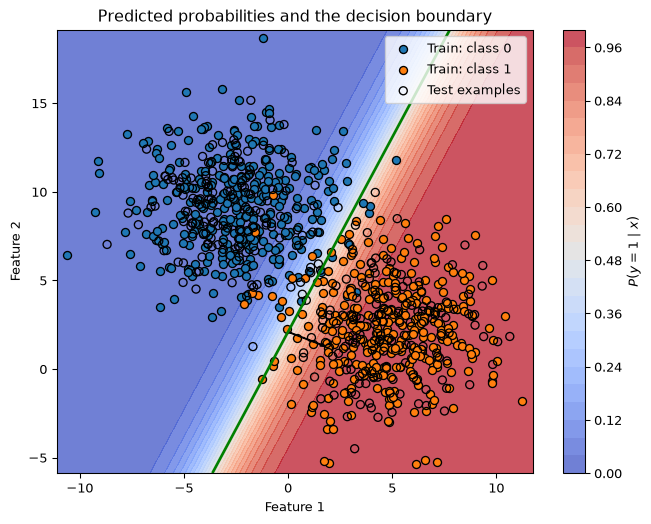

In [7]:
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1_min, x1_max, 250),
    np.linspace(x2_min, x2_max, 250),
)
grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])
probability_grid = model.predict_proba(grid).reshape(x1_grid.shape)

plt.figure(figsize=(8, 6))
surface = plt.contourf(
    x1_grid,
    x2_grid,
    probability_grid,
    levels=25,
    cmap="coolwarm",
    alpha=0.75,
)
plt.colorbar(surface, label=r"$P(y=1\mid x)$")
plt.contour(
    x1_grid,
    x2_grid,
    probability_grid,
    levels=[0.5],
    colors="green",
    linewidths=2,
)

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    color="tab:blue",
    edgecolor="black",
    label="Train: class 0",
)
plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color="tab:orange",
    edgecolor="black",
    label="Train: class 1",
)
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    facecolors="none",
    edgecolors="black",
    marker="o",
    label="Test examples",
)

# Draw the unit normal vector from a point on the boundary where x1 = 0.
normal = model.coef_
normal_unit = normal / np.linalg.norm(normal)
boundary_point = np.array([0.0, -model.intercept_ / normal[1]])
plt.arrow(
    boundary_point[0],
    boundary_point[1],
    normal_unit[0] * 2,
    normal_unit[1] * 2,
    width=0.03,
    head_width=0.18,
    color="black",
    length_includes_head=True,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Predicted probabilities and the decision boundary")
plt.legend(loc="best")
plt.show()

The sigmoid acts on the linear score $\theta_0+w^\top x$. The signed
distance to the boundary divides that score by $\lVert w\rVert$; the two
quantities therefore differ whenever the weight vector is not a unit
vector.